In [1]:
import sys
sys.path.append("..")

In [2]:
import numpy as np
from feature_analysis.feature_extract import FeatureExtractManager

In [3]:
kernels_dataset = np.load("../Kernels_datasets_numpy/kernel_dataset_1.npy", allow_pickle=True).item()
feature_manager = FeatureExtractManager(kernels_dataset)
df_features = feature_manager.extract_all_to_dataframe()

Iniciando extracción radiómica (First-Order, GLCM, LDOP-Gradients)...
  -> Minando características para clase: Bleeding (2884 parches)
  -> Minando características para clase: Ischemia (2884 parches)
  -> Minando características para clase: Normal (2884 parches)
--------------------------------------------------
EXTRACCIÓN COMPLETADA.
Dataset estructurado final: 8652 filas (ejemplos) x 15 columnas (features + label)
--------------------------------------------------


In [4]:
feature_list = ['variance', 'glcm_correlation',     # Obtenida de análisis preliminares
                'energy_1st', 'glcm_entropy', 
                'skewness','kurtosis']


--- RANKING DE CARACTERÍSTICAS ---
        Caracteristica  Score_Final  Info_Mutua  RF_Importancia
0             variance     1.000000    0.314981        0.123662
1     glcm_correlation     0.951788    0.285067        0.123482
2           energy_1st     0.624720    0.157984        0.092483
3              mean_hu     0.578559    0.139931        0.088154
4         glcm_entropy     0.570279    0.178684        0.070892
5             skewness     0.511823    0.092085        0.090433
6             kurtosis     0.502315    0.133763        0.071719
7          glcm_energy     0.480719    0.145342        0.061832
8   ldop_grad_135_mean     0.308454    0.076067        0.046424
9    ldop_grad_90_mean     0.298865    0.055521        0.052119
10   ldop_grad_45_mean     0.282588    0.065166        0.044306
11    glcm_homogeneity     0.268749    0.042474        0.049793
12       glcm_contrast     0.265437    0.051207        0.045545
13    ldop_grad_0_mean     0.214432    0.035348        0.039156


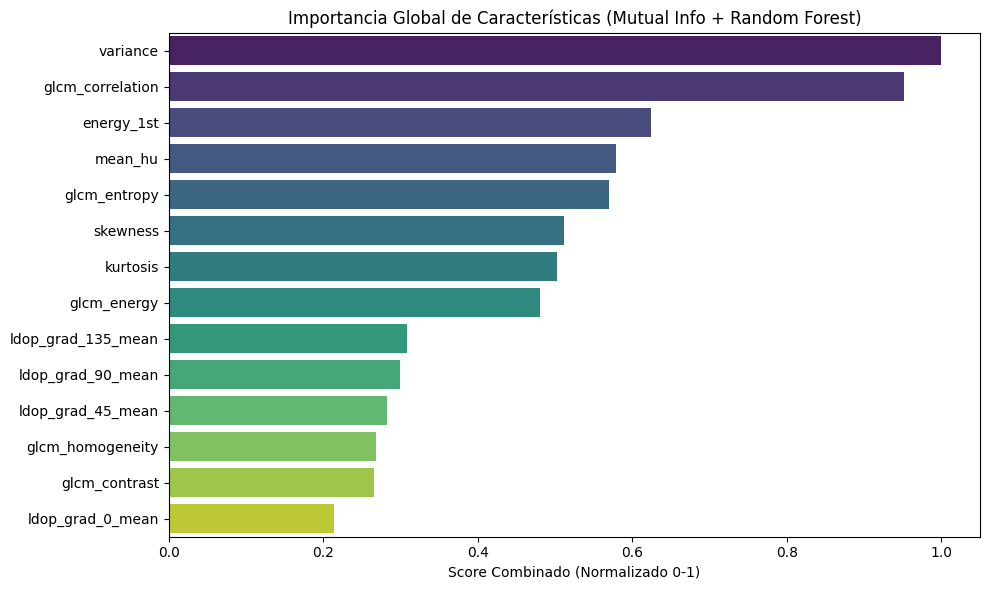

Calculando matriz de correlación cruzada...


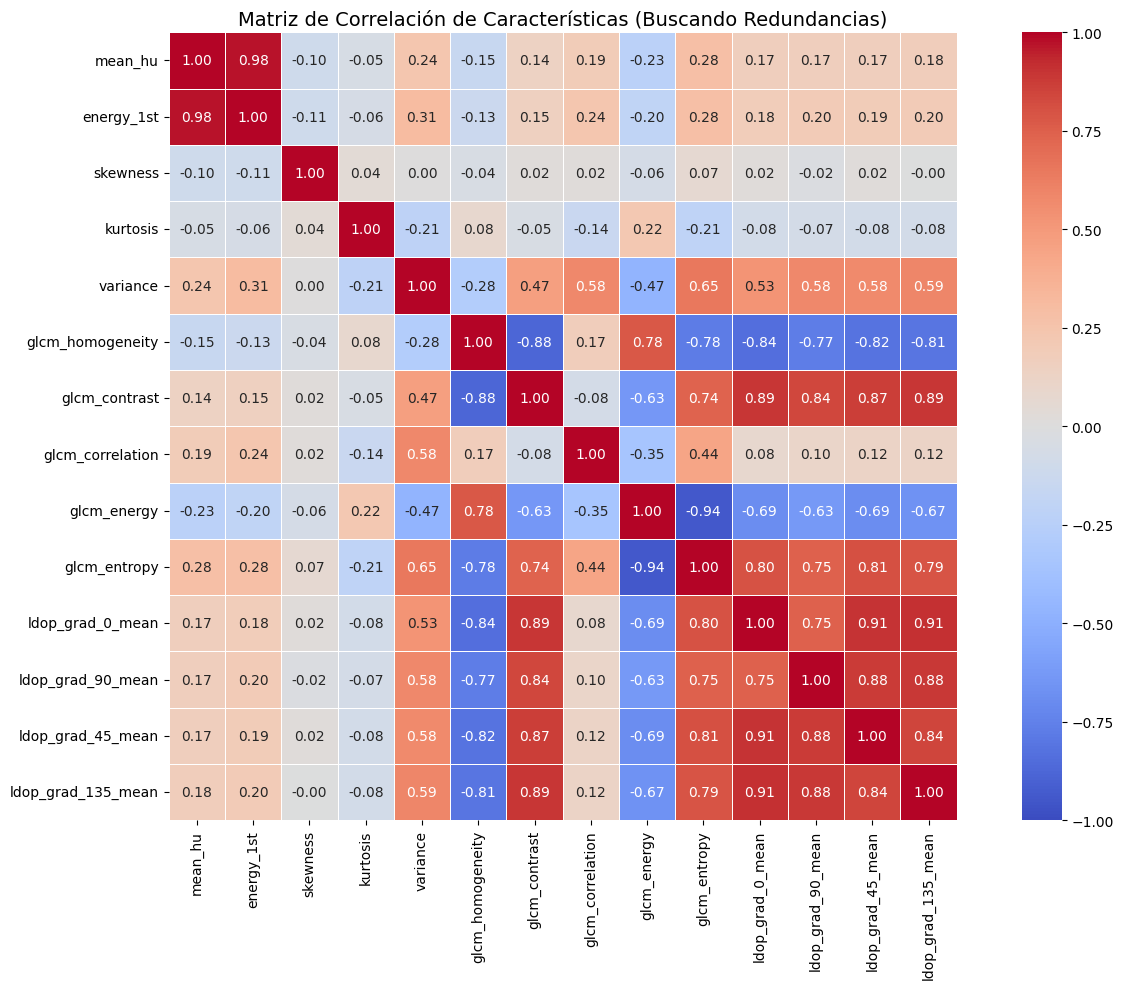

In [5]:
from feature_evaluation.feature_evaluator import FeatureEvaluator
evaluator = FeatureEvaluator(df_features, analysis=True)

In [6]:
ranking = evaluator.rank_feature_combinations(feature_list, max_size=6)

Analizando combinaciones de '['variance', 'glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']'...

--- TOP 5 MEJORES COMBINACIONES ---
    num_features                                           features  accuracy
61             5  glcm_correlation, energy_1st, glcm_entropy, sk...  0.771808
58             5  variance, glcm_correlation, energy_1st, skewne...  0.764298
60             5  variance, energy_1st, glcm_entropy, skewness, ...  0.760254
62             6  variance, glcm_correlation, energy_1st, glcm_e...  0.760254
42             4   variance, glcm_correlation, energy_1st, skewness  0.755633
56             5  variance, glcm_correlation, energy_1st, glcm_e...  0.755055
47             4       variance, energy_1st, glcm_entropy, skewness  0.751589
51             4  glcm_correlation, energy_1st, glcm_entropy, sk...  0.742345
49             4           variance, energy_1st, skewness, kurtosis  0.737146
57             5  variance, glcm_correlation, energy_1st, glcm_

In [9]:
best_features_kernel_1 = ['glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']

In [10]:
models = evaluator.run_models_benchmark(best_features_kernel_1)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 77.07%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 75.16%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 48.64%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 48.24%
..............................

GANADOR DEL BENCHMARK: Random Forest con 77.07% de precisión.


In [11]:
best_features_kernel_2 = ['variance', 'glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_2)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 76.66%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 75.22%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 48.64%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 52.98%
..............................

GANADOR DEL BENCHMARK: Random Forest con 76.66% de precisión.


In [12]:
best_features_kernel_3 = ['variance', 'glcm_correlation', 'energy_1st', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_3)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 76.49%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 75.22%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 48.64%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 52.92%
..............................

GANADOR DEL BENCHMARK: Random Forest con 76.49% de precisión.


In [13]:
best_features_kernel_4 = ['glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_4)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 77.07%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 75.16%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 48.64%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 48.24%
..............................

GANADOR DEL BENCHMARK: Random Forest con 77.07% de precisión.
